In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import VPR_im2im.utils.torch_dataloader as td
from utils.logger import *
from configs.loader import cfg
from VPR_im2im.utils.metrics import compute_metrics_from_scores
from Model.models import *
from VPR_im2im.utils.data_loader import *
from evaluation import *
import pickle as pkl
import re
import json

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
spot_odo = 'dataset/spot/millerst/strayscanner/odometry.csv'
iphone_odo = 'dataset/3578aa5730/odometry_spot_aligned.csv'

spot_df = pd.read_csv(spot_odo)
iphone_df = pd.read_csv(iphone_odo)

In [2]:
dino_encoder = DinoModel(cfg)

[DINO] Loading facebook/dinov2-large → cuda


In [6]:
dataset = load_spot_data(step=5, window_size=5)


100%|██████████| 214/214 [00:10<00:00, 21.38it/s]


In [13]:
dataset["query_traj"] = np.array(dataset["query_traj"])

In [15]:
with open("spot_dataset_w_gt_5m.pkl", "wb") as f:
    pickle.dump(dataset, f)

In [5]:
methods = {
    # "domain_patch_vlad": {"patches": True, "agg_method": "domain_vlad", "num_clusters":32, "grayscale": False},

    "patch_vlad": {"patches": True, "agg_method": "vlad", "num_clusters":32, "grayscale": False},

    # "patch_gem": {"patches": True, "agg_method": "gem", "num_clusters":32, "grayscale": False},

    # "patch_gmp": {"patches": True, "agg_method": "gmp", "num_clusters":32, "grayscale": False},

    # "patch_gap": {"patches": True, "agg_method": "gap", "num_clusters":32, "grayscale": False}
}


with open("spot_dataset_w_gt_5m.pkl", 'rb') as file: 
    dataset = pkl.load(file)

# dataset = load_data("dataset/AnyLoc2023-Public-Data/Public/Datasets-All/17places")
ground_truth = dataset["ground_truth"]

# all_frames = dataset['query_images']
ts = np.array(dataset['ts'])

encoded_data = prepare_embeddings(dino_encoder, 
                                images=dataset["db_images"],
                                query_frames=dataset["query_images"],
                                methods=methods, 
                                ts=ts,
                                cropping=False,
                                grayscale=False)

# encoded_data_grayscale = prepare_embeddings(dino_encoder, 
#                                 images=dataset["db_images"],
#                                 query_frames=dataset["query_images"],
#                                 methods=methods, 
#                                 ts=ts,
#                                 cropping=False,
#                                 grayscale=True)



100%|██████████| 50/50 [00:09<00:00,  5.06it/s]


Fitting VLAD centers with KMeans...


100%|██████████| 50/50 [00:01<00:00, 37.14it/s]


Embedding queries for method: patch_vlad


100%|██████████| 20/20 [00:00<00:00, 36.44it/s]


In [7]:
with open('graph_dataset/spot_aligned_graph.json', 'r') as graph:
    fixed_g = json.load(graph)

In [8]:
import time

Localization time: 0.0187 seconds


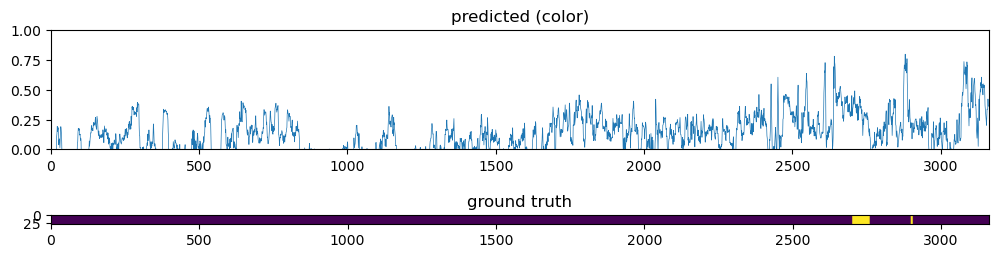

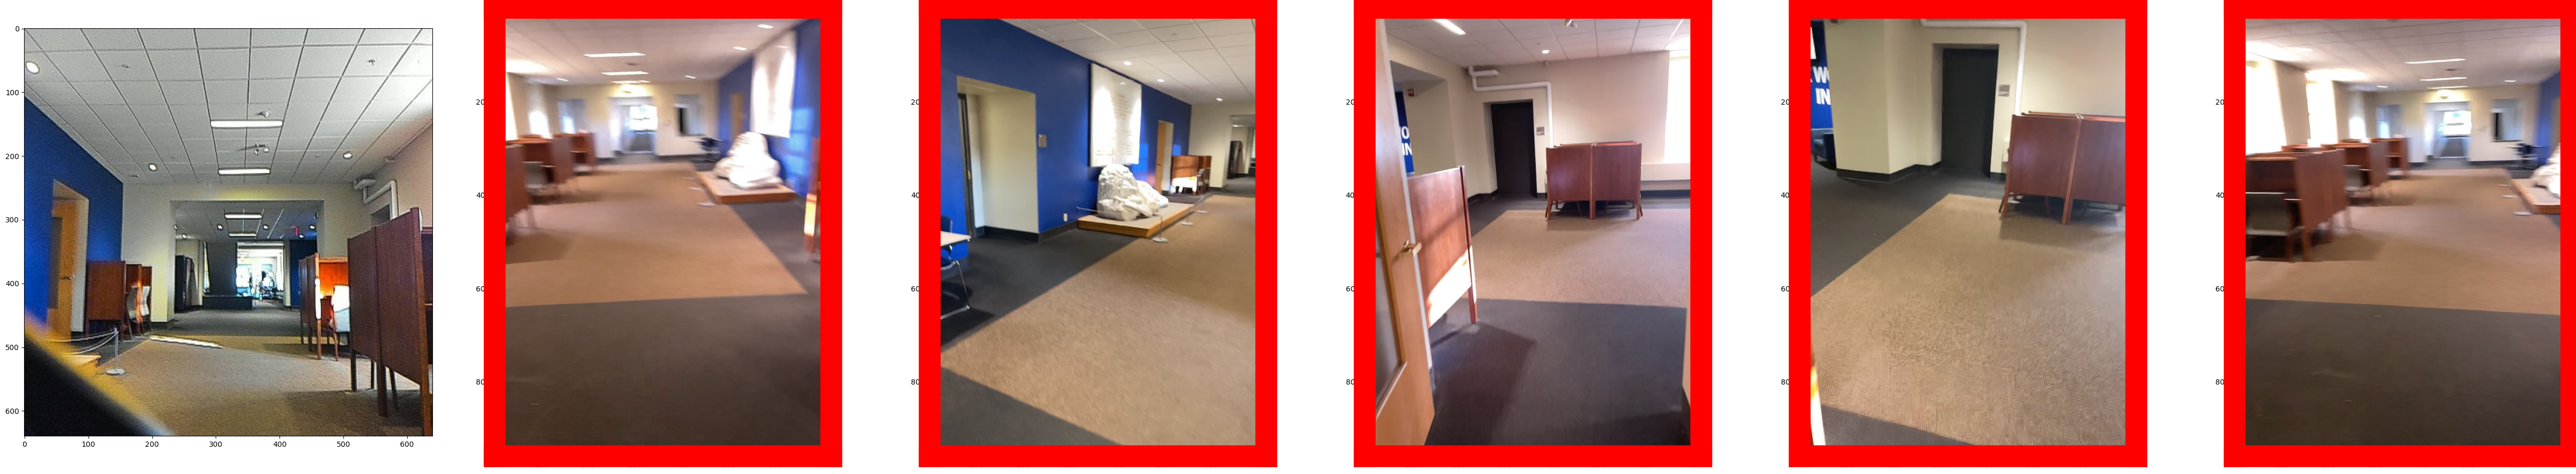

[[     6.0648      10.426      5.4547      9.2675      8.2577]]

📍 SUBGRAPH STATE SUMMARY
Likely Current Room: **Miller Street 2**

📊 Objects per room (within window):
  - Miller Street 2: 5 objects
  - Conference Rooms: 4 objects
  - Miller Street 3: 2 objects

🛋️  Objects detected in Miller Street 2:
  beige kitchen cabinet, Black vending machine, Glass door refrigerator, vending machine stocked, Glass refrigerator door

🔗 Object Relations (Induced Subgraph):
  - [Glass door refrigerator] left_of [Glass refrigerator door]
  - [Glass refrigerator door] right_of [Glass door refrigerator]
  - [Black vending machine] next_to [Glass door refrigerator]
  - [Glass door refrigerator] next_to [Black vending machine]
  - [Glass door refrigerator] near [vending machine stocked]
  - [vending machine stocked] near [Glass door refrigerator]
  - [white curtain door] right_of [Glass office wall]
  - [Glass office wall] left_of [white curtain door]
  - [brown wooden door] near [brown wooden door]
  -

In [22]:
from scipy.ndimage import gaussian_filter1d

t = 200
start_time = time.time()
im_scores, _, pred = localize(encoded_data, ground_truth, "patch_vlad", t, 3)
# im_scores_grayscale, _, _ = localize(encoded_data, ground_truth, "patch_vlad", t, 3)
end_time = time.time()

print(f"Localization time: {end_time - start_time:.4f} seconds")

stacked_scores = np.vstack([im_scores for _ in range(len(im_scores)//100)])
# stacked_scores_grayscale = np.vstack([im_scores_grayscale for _ in range(len(im_scores_grayscale)//10)])


stacked_truth = np.zeros_like(stacked_scores)
stacked_truth[:,ground_truth[t][1]] = 1

fig, axes = plt.subplots(2, 1, figsize=(10, 3))


axes[0].set_title('predicted (color)')
axes[0].plot([i for i in range(stacked_truth.shape[1])], im_scores, linewidth=0.5)
axes[0].set_xlim(0, stacked_truth.shape[1])
axes[0].set_ylim(0, 1)

# axes[1].set_title('predicted (grayscale)')
# axes[1].imshow(stacked_scores_grayscale)
axes[1].set_title('ground truth')
axes[1].imshow(stacked_truth)

plt.tight_layout()
plt.show()

im_scores_sortedindicies = np.argsort(-im_scores)
sorted_db_images = dataset["db_images"][im_scores_sortedindicies]

top_k = 5
height = 10
query_pos = [dataset["query_traj"][t]]
top_k_pos = dataset["db_traj"][im_scores_sortedindicies[:top_k]]

localization_errors = cdist(query_pos, top_k_pos)

fig, axes = plt.subplots(1, top_k + 1, figsize=(height * top_k, height))
for i, ax in enumerate(np.atleast_1d(axes)):
    if i == 0:
        ax.imshow(dataset["query_images"][np.array(dataset["ts"]) == t][0])
        continue
    ax.imshow(sorted_db_images[i])
    # ax.axis('off')
    # Add green border if image is part of ground truth
    if im_scores_sortedindicies[i] in ground_truth[t][1]:
        for spine in ax.spines.values():
            spine.set_edgecolor('green')
            spine.set_linewidth(30)
    else:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(30)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()
print(localization_errors)
res = retrieve_subgraphs(dataset, im_scores_sortedindicies, fixed_g, window=3)

In [28]:
from PIL import Image
from tqdm import tqdm
import io

def generate_localization_gif(dataset, encoded_data, ground_truth, 
                              method="patch_vlad", n_views=3, top_k=5, 
                              output_path="localization_results.gif", max_t=None):
    """
    Iterates through all timestamps, generates a combined localization plot, 
    and saves the sequence as an animated GIF.
    """
    ts_array = np.array(dataset["ts"])
    if not max_t:
        max_t = int(np.max(ts_array))
    
    frames = []
    
    res = {
        "loc_errors": [],
        "Hit@1": 0.0, "Hit@3": 0.0, "Hit@5": 0.0, "MRR": 0.0, "N": 0
    }

    print(f"Generating GIF frames (0 to {max_t})...")
    for t in tqdm(range(max_t + 1)):
        # 1. Skip if no query images exist for this timestamp (e.g., our sensor drop at t=133)
        query_mask = (ts_array == t)
        if not np.any(query_mask):
            continue
            
        # 2. Get Scores
        # Note: I'm using your snippet exactly, but ensure you are passing the 
        # correct encoded_data if your color/grayscale datasets are separated!
        im_scores, _, _ = localize(encoded_data, ground_truth, method, t, n_views)
        # im_scores_grayscale, _, _ = localize(encoded_data, ground_truth, method, t, n_views)

        # 3. Prepare visual arrays
        stacked_scores = np.vstack([im_scores for _ in range(max(1, len(im_scores)//10))])
        # stacked_scores_grayscale = np.vstack([im_scores_grayscale for _ in range(max(1, len(im_scores_grayscale)//10))])
        
        stacked_truth = np.zeros_like(stacked_scores)
        correct_indices = ground_truth[t][1]
        if len(correct_indices) > 0:
            stacked_truth[:, correct_indices] = 1

        query_image = dataset["query_images"][query_mask][0]
        
        im_scores_sortedindices = np.argsort(-im_scores)
        sorted_db_images = dataset["db_images"][im_scores_sortedindices[:top_k]]

        query_pos = [dataset["query_traj"][t]]
        top_k_pos = dataset["db_traj"][im_scores_sortedindices[:top_k]]

        localization_errors = cdist(query_pos, top_k_pos)[0]
        res["loc_errors"].append(localization_errors)

        hot_coded_correct = np.zeros(im_scores_sortedindices.shape[0])
        if len(correct_indices) > 0:
            hot_coded_correct[correct_indices] = 1.0
            
        metrics, _, _ = compute_metrics_from_scores(im_scores, hot_coded_correct, ks=(1, 3, 5))

        res["Hit@1"] += metrics.get("Hit@1", metrics.get("Acc", 0.0))
        res["Hit@3"] += metrics["Hit@3"]
        res["Hit@5"] += metrics["Hit@5"]
        res["MRR"] += metrics["MRR"]
        res["N"] += 1

        # ==========================================
        # 4. Build the Figure Layout
        # ==========================================
        fig = plt.figure(figsize=(16, 10))
        # Top half for score heatmaps, bottom half for images
        gs = fig.add_gridspec(2, 1, height_ratios=[1, 2])
        
        # --- Top Half: Scores ---
        gs_top = gs[0].subgridspec(2, 1, hspace=0.4)
        
        ax_color = fig.add_subplot(gs_top[0, 0])
        # ax_color.set_title(f'Predicted (Color) - t={t}')
        # ax_color.imshow(stacked_scores, aspect='auto', cmap='viridis')
        # ax_color.axis('off')
        
        
        ax_color.set_title(f'predicted (color) - t={t}')
        ax_color.plot([i for i in range(stacked_truth.shape[1])], im_scores**3, linewidth=0.5)
        ax_color.set_xlim(0, stacked_truth.shape[1])
        ax_color.set_ylim(0, 1)

        # ax_gray = fig.add_subplot(gs_top[1, 0])
        # ax_gray.set_title('Predicted (Grayscale)')
        # ax_gray.imshow(stacked_scores_grayscale, aspect='auto', cmap='viridis')
        # ax_gray.axis('off')

        ax_gt = fig.add_subplot(gs_top[1, 0])
        ax_gt.set_title('Ground Truth')
        ax_gt.imshow(stacked_truth, aspect='auto', cmap='binary')
        ax_gt.axis('off')

        # --- Bottom Half: Images ---
        gs_bottom = gs[1].subgridspec(1, top_k + 1, wspace=0.1)
        
        # Query Image (Leftmost)
        ax_query = fig.add_subplot(gs_bottom[0, 0])
        ax_query.set_title('Query Image', fontweight='bold')
        ax_query.imshow(query_image)
        ax_query.axis('off')
        
        # Top K Matches
        for i in range(top_k):
            ax_match = fig.add_subplot(gs_bottom[0, i + 1])
            ax_match.set_title(f'Match #{i+1} | Loc Error {localization_errors[i]:.2f}')
            
            # If we don't have enough DB images for some reason, break safely
            if i < len(sorted_db_images):
                ax_match.imshow(sorted_db_images[i])
            ax_match.axis('off')
            
            # Highlight if it's a correct match (Green border)
            if im_scores_sortedindices[i] in correct_indices:
                for spine in ax_match.spines.values():
                    spine.set_edgecolor('green')
                    spine.set_linewidth(10)
                ax_match.axis('on') # Turn axis on just to show the green border
                ax_match.set_xticks([])
                ax_match.set_yticks([])
            else:
                for spine in ax_match.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(10)
                ax_match.axis('on') # Turn axis on just to show the green border
                ax_match.set_xticks([])
                ax_match.set_yticks([])

        plt.tight_layout()
        
        # ==========================================
        # 5. Convert Plot to Image Buffer & Append
        # ==========================================
        # Draw the canvas to an RGB buffer
        fig.canvas.draw()
        img_arr = np.array(fig.canvas.buffer_rgba())
        # img_arr = img_arr.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(Image.fromarray(img_arr[..., :3].copy())) # Drop Alpha channel
        
        # Close the figure to free memory! Extremely important inside loops.
        plt.close(fig)

    # ==========================================
    # 6. Save as GIF
    # ==========================================
    print(f"Saving GIF to {output_path}...")
    if frames:
        # duration is in milliseconds per frame. 500ms = 2 fps.
        frames[0].save(output_path, format='GIF',
                       append_images=frames[1:],
                       save_all=True,
                       duration=500, loop=0)
        print("Done!")
    else:
        print("Error: No frames were generated.")

    res["Hit@1"] /= (res["N"] *0.01)
    res["Hit@3"] /= (res["N"] * 0.01)
    res["Hit@5"] /= (res["N"] * 0.01)
    res["MRR"] /= (res["N"] * 0.01)
    return res
# Run it:


In [29]:
res = generate_localization_gif(dataset, encoded_data, ground_truth, method="patch_vlad", n_views=10, output_path="localization_results_spot_5m.gif", top_k=5)

Generating GIF frames (0 to 213)...


  0%|          | 0/214 [00:00<?, ?it/s]

100%|██████████| 214/214 [00:44<00:00,  4.82it/s]


Saving GIF to localization_results_spot_5m.gif...
Done!


In [7]:
loc_errors = np.array(res["loc_errors"])

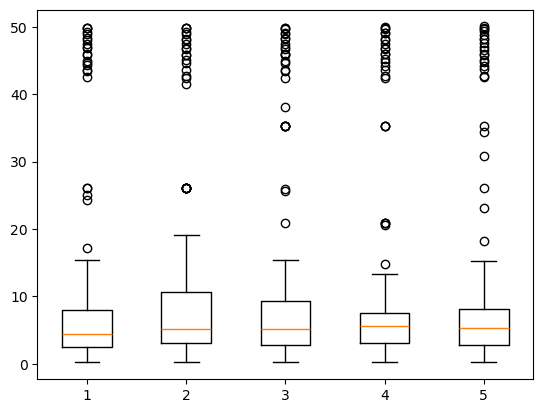

In [8]:
plt.boxplot(loc_errors[:, :])

plt.show()

In [9]:
loc_errors.std(0)

array([     12.291,      12.469,      12.914,      12.392,      12.376])

In [70]:
def parse_svg_path(path_str):
    """
    Extracts (x, y) tuples from an SVG path string like 'M1,2L3,4L5,6Z'
    """
    # Find all numeric values (including negatives and decimals)
    coords = re.findall(r"[-+]?\d*\.\d+|\d+", path_str)
    
    # Group them into pairs of (x, y)
    points = [(float(coords[i]), float(coords[i+1])) for i in range(0, len(coords), 2)]
    return points

def is_point_in_polygon(x, y, polygon):
    """
    Determines if a 2D point (x, y) is inside a polygon using Ray-Casting.
    """
    n = len(polygon)
    inside = False

    p1x, p1y = polygon[0]
    for i in range(1, n + 1):
        # Wrap around to the first point to close the polygon loop
        p2x, p2y = polygon[i % n]
        
        # Check if the horizontal ray from (x, y) intersects the edge (p1, p2)
        if y > min(p1y, p2y) and y <= max(p1y, p2y) and x <= max(p1x, p2x):
            if p1y != p2y:
                # Calculate the x-coordinate of the intersection
                x_inter = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                if p1x == p2x or x <= x_inter:
                    inside = not inside
                    
        p1x, p1y = p2x, p2y

    return inside

class RoomLocator:
    def __init__(self, json_data):
        self.rooms = []
        for item in json_data['rooms']:
            points = parse_svg_path(item['path'])
            if len(points) >= 3: # A valid polygon needs at least 3 points
                self.rooms.append({
                    "name": item['room'],
                    "polygon": points
                })

    def get_room(self, x, y, z=0):
        """
        Given an x, y (and optional z) coordinate, returns the room name.
        Note: z is currently ignored as the provided paths are 2D.
        """
        for room in self.rooms:
            if is_point_in_polygon(x, y, room['polygon']):
                return room['name']
        
        return "Outside/Unknown"

# --- Usage Example ---
with open('graph_dataset/rooms.json', 'rb') as room_data:
    data = json.load(room_data)
# 1. Initialize the locator with your JSON data
locator = RoomLocator(data)

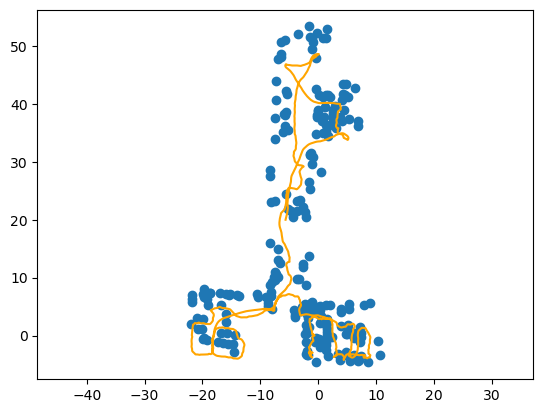

In [71]:
graph_path = "./graph_dataset/graph.json"
with open(graph_path, 'r') as f:
    g = json.load(f)
fixed_g = g.copy()
for n in fixed_g['nodes']:
    x, y, z = n['position']
    n['room'] = locator.get_room(x,z)
    # Switch coordinates
    x, y, z = x, z, y
    # Rotate 90 degrees around new z-axis
    x, y = y, -x
    # Mirror across the y-axis
    x = -x
    # Translate by [0, 0, 0] (no change in this case)
    x = x + iphone_df[' x'][0] - spot_df['x'][0]
    y = y + iphone_df[' y'][0] - spot_df['y'][0]
    z = z + iphone_df[' z'][0] - spot_df['z'][0]
    n['position'] = x, y, z
    
nodes = pd.DataFrame(fixed_g['nodes'])
plt.axis('equal')
plt.scatter(np.array(list(nodes['position']))[:, 0], np.array(list(nodes['position']))[:, 1])
plt.plot(iphone_df[' x'], iphone_df[' y'], c='orange')
plt.show()

In [72]:
with open('./graph_dataset/spot_aligned_graph.json', 'w') as f:
    json.dump(fixed_g, f)

In [88]:
t = 200
print(fixed_g['nodes'][t]['class_name'])
print(fixed_g['nodes'][t]['room'])

Glass office doors
Conference Rooms
